<a href="https://colab.research.google.com/github/lili-codelab/comp-linguistics/blob/main/RNN_pr_li.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **RNN/LSTM**

Цель семинара: получить практический опыт работы с RNN (LSTM) в PyTorch на задачах генерации последовательностей

Мы разберем полный пайплайн разработки от препроцессинга данных до обучения и экспериментов с гиперпараметрами

Кстати, что мы называем **пайплайном**?

В Google Colab (рекомендуется активировать GPU: `Среда выполнения → Сменить среду выполнения → T4 GPU`)

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

### **ЧАСТЬ 1: ДЕМО**
*   **Задача модели:** предсказание случайного временного ряда (синусоида)
*   **Цель демонстрации:** показать полный и минимальный рабочий пайплайн RNN на задаче, связанной с обработкой данных, передающих изменения во времени
*   **План:**
    1.  Подготовка последовательностей (sequences)
    2.  Архитектура `nn.LSTM`
    3.  Обучение модели
    4.  Получение метрик оценки
    5.  Визуализация и интерпретация результата

### 1. ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ

In [23]:
def generate_sine_wave(seq_length=1000, periods=5):
    """Генерация синусоиды."""#пластмассовая? из 1000 точек создает синусоиды из 5 фаз
    x = np.linspace(0, periods * 2 * np.pi, seq_length)
    y = np.sin(x)
    return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

Длина временного ряда: 1000


In [24]:
# Параметры последовательностей
SEQ_LEN = 50  # Длина входной последовательности для предсказания - размер, кот будет изучать модель
BATCH_SIZE = 16 # в сверточной нейросети важно чтобы все последователньости были одинаковы - один в один, иначе чисто технически нее построить /
                # важно размер бача - ограничение, пакет передаваемых на вход данных, какой длины будет кусочек, кот определяет размер пакета (заданные числами и нейросеть обрабатывает именно их)
                # принято степень двойки, но можно 1. если мощная оперативка, и не грузные данные - 120 ок

In [25]:
def create_sequences(data, seq_len):
    """Создание пар (входная последовательность, целевое значение)."""
    sequences = []
    targets = []
    for i in range(len(data) - seq_len - 1):
        seq = data[i:i + seq_len] # сбор цепочки (входная посл как вся цепочка, кроме таргета)
        target = data[i + seq_len] # последняя точка для таргета
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)
    # создание контекстного окна \ предсказ след наиболее вероятного числа

In [26]:
# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")
# макс длина 50, не исключены некоторые потери

Форма X (последовательности): (949, 50)
Форма y (цели): (949,)


In [27]:
# Преобразование в тензоры PyTorch и добавление размерности для признаков
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [примеры, SEQ_LEN, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [примеры, 1]
print(f"Форма X (тензор): {X.shape}")
print(f"Форма y (тензор): {y.shape}")

Форма X (тензор): torch.Size([949, 50, 1])
Форма y (тензор): torch.Size([949, 1])


In [28]:
# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [29]:
### 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM - считает связи последоваетльности, но сама ничего не генерирует
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
# контекс и связи: или как нейронка определяет, что будет значит слово, следующее за конкретным
        self.lstm = nn.LSTM(                    # этот слой необходим для (точка уже смоделирована) моделирования вероятности ее появления, признаков того, что точка (таргет) появится когда за ней следует ее ппоследовательность по конкретной дуге (контекст: привет как дела => за ним последует знак вопроса)
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # формат [batch, seq_len, features]
        )
        self.fc = nn.Linear(hidden_size, output_size) # линейный слой предсказания того, что следует за таргетом

    def forward(self, x):
        # Инициализация скрытого состояния и состояния ячейки
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size) # вектор скрытого состояния (длинный диалог с чат гпт)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size) # контекст (текущий промпт)

        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Берем только последний выход последовательности для предсказания
        out = self.fc(out[:, -1, :]) # генератор текста, иначе просто эмбединговая модель
        return out
        # вес зедсь информация о том в каком контексте в принципе слово встречается используется

In [30]:
# Инициализация модели
model = SineLSTM()
print(f"Модель:\n{model}")

Модель:
SineLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### 3. ОБУЧЕНИЕ МОДЕЛИ

In [31]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 0.01

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Тренировочный цикл
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()

    # Прямой проход
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Обратное распространение
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха [{epoch+1}/{EPOCHS}], '
              f'Ошибка обучения: {loss.item():.6f}, '
              f'Ошибка теста: {test_loss.item():.6f}')

Эпоха [5/20], Ошибка обучения: 0.108591, Ошибка теста: 0.133557
Эпоха [10/20], Ошибка обучения: 0.035928, Ошибка теста: 0.056389
Эпоха [15/20], Ошибка обучения: 0.022757, Ошибка теста: 0.021401
Эпоха [20/20], Ошибка обучения: 0.016132, Ошибка теста: 0.015601


### 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

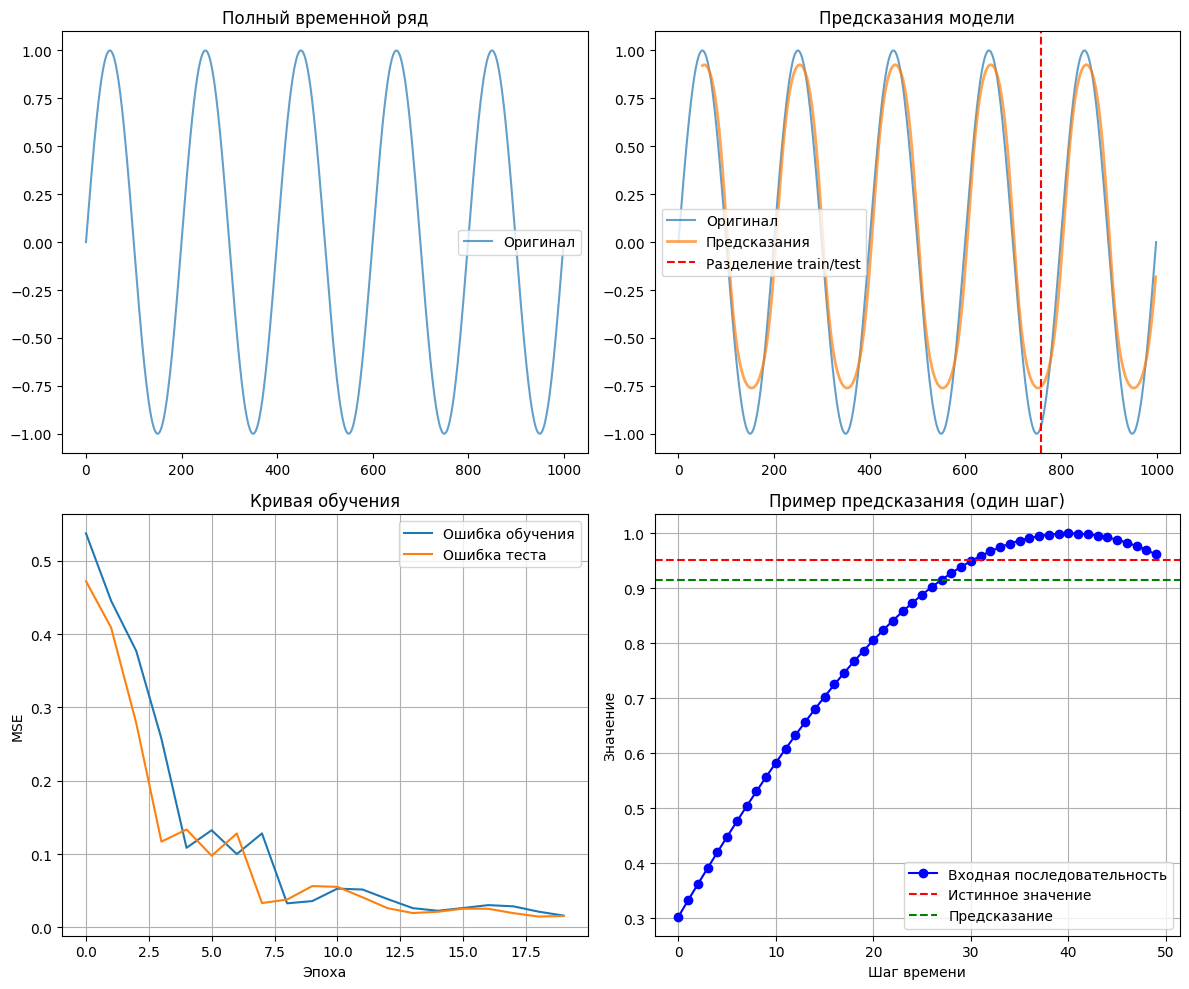

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Оригинальные данные и предсказания
axes[0, 0].plot(data, label='Оригинал', alpha=0.7)
axes[0, 0].set_title('Полный временной ряд')
axes[0, 0].legend()

# График 2: Предсказания на тестовой выборке
model.eval()
with torch.no_grad():
    all_predictions = model(X).numpy()

# Создание массива для отображения предсказаний
pred_series = np.full_like(data, np.nan)
pred_series[SEQ_LEN:SEQ_LEN + len(all_predictions)] = all_predictions.squeeze()

axes[0, 1].plot(data, label='Оригинал', alpha=0.7)
axes[0, 1].plot(pred_series, label='Предсказания', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=split_idx, color='r', linestyle='--', label='Разделение train/test')
axes[0, 1].set_title('Предсказания модели')
axes[0, 1].legend()

# График 3: Ошибки обучения и теста
axes[1, 0].plot(train_losses, label='Ошибка обучения')
axes[1, 0].plot(test_losses, label='Ошибка теста')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Кривая обучения')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График 4: Пример одного предсказания
sample_idx = split_idx + 50
axes[1, 1].plot(range(SEQ_LEN), X[sample_idx].squeeze().numpy(),
                'bo-', label='Входная последовательность')
axes[1, 1].axhline(y=y[sample_idx].item(), color='r', linestyle='--',
                   label='Истинное значение')
axes[1, 1].axhline(y=all_predictions[sample_idx].item(), color='g',
                   linestyle='--', label='Предсказание')
axes[1, 1].set_xlabel('Шаг времени')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Пример предсказания (один шаг)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Кривая обучения должна снижаться на обеих выборках
2. Предсказания должны следовать за оригинальным рядом
3. Разрыв между train/test loss указывает на переобучение
4. Модель учится предсказывать следующий шаг синусоиды

Take aways:

1. Подготовка последовательностей: как из временного ряда создаются пары (окно истории -> целевое значение)?

2. Архитектура LSTM: batch_first=True, почему берем out[:, -1, :]

3. Цикл обучения: разделение на model.train() и model.eval(), логика .zero_grad(), .backward(), .step()

4. Визуализация: как интерпретировать каждый из 4-х графиков?

---

# ПРАКТИКА

1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [34]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])


Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [35]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример:", texts[:500])

# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
texts[:20], text_as_int[:20]

Общая длина текста (символов): 815340
Пример: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 
Размер словаря (уникальных символов): 39


('? mcgrath rentcorp s',
 [12, 0, 25, 15, 19, 30, 13, 32, 20, 0, 30, 17, 26, 32, 15, 27, 30, 28, 0, 31])

4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [36]:
seq_length = 100

# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

print(f"\nКоличество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)


Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240])


5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [37]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO 5.1: Определите слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # TODO 5.2: Реализуйте forward pass
        # Шаг 1: Примените слой эмбеддинга
        embedded = self.embedding(x)

        # Шаг 2: Прямой проход через LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        # Шаг 3: Возьмите только последний выход LSTM
        lstm_out = lstm_out[:, -1, :]

        # Шаг 4: Примените полносвязный слой
        output = self.fc(lstm_out)

        return output, hidden

device = torch.device('cuda')

# TODO 5.3: Инициализируйте модель
model = CharLSTM(vocab_size=vocab_size, hidden_size=128, num_layers=2)
model = model.to(device)
print(f"\nМодель:\n{model}")


Модель:
CharLSTM(
  (embedding): Embedding(39, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=39, bias=True)
)


6. ОБУЧЕНИЕ МОДЕЛИ

In [38]:
EPOCHS = 4
LEARNING_RATE = 0.005

# TODO 6.1: Определите функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# TODO 6.2: Реализуйте функцию генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы, фильтруя символы, которых нет в словаре
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            # Если символа нет в словаре, используем первый попавшийся символ
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]  # На случай пустого seed

    with torch.no_grad():
        # Создаем начальное hidden state
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        # "Прогреваем" модель на seed последовательности
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Начинаем генерацию
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            # Применяем temperature для управления случайностью
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            # Выбираем следующий символ на основе вероятностей
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем вход для следующей итерации
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

# TODO 6.3: Реализуйте тренировочный цикл
train_losses = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 2 == 0: # Генерация текста для мониторинга прогресса
        seed = "The company said"        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')


Начало обучения...
Эпоха [1/4], Батч [50/25477], Потеря: 2.8917
Эпоха [1/4], Батч [100/25477], Потеря: 2.4357
Эпоха [1/4], Батч [150/25477], Потеря: 2.6001
Эпоха [1/4], Батч [200/25477], Потеря: 2.3420
Эпоха [1/4], Батч [250/25477], Потеря: 2.6508
Эпоха [1/4], Батч [300/25477], Потеря: 2.3472
Эпоха [1/4], Батч [350/25477], Потеря: 2.4238
Эпоха [1/4], Батч [400/25477], Потеря: 1.8917
Эпоха [1/4], Батч [450/25477], Потеря: 1.8983
Эпоха [1/4], Батч [500/25477], Потеря: 1.6718
Эпоха [1/4], Батч [550/25477], Потеря: 2.0815
Эпоха [1/4], Батч [600/25477], Потеря: 2.1441
Эпоха [1/4], Батч [650/25477], Потеря: 2.2698
Эпоха [1/4], Батч [700/25477], Потеря: 2.1180
Эпоха [1/4], Батч [750/25477], Потеря: 2.0993
Эпоха [1/4], Батч [800/25477], Потеря: 1.6469
Эпоха [1/4], Батч [850/25477], Потеря: 2.0867
Эпоха [1/4], Батч [900/25477], Потеря: 1.8315
Эпоха [1/4], Батч [950/25477], Потеря: 2.0669
Эпоха [1/4], Батч [1000/25477], Потеря: 2.1312
Эпоха [1/4], Батч [1050/25477], Потеря: 2.0510
Эпоха [1/4], 

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 13 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

In [39]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [52]:
import time
import torch.nn.utils

def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text

    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]

    with torch.no_grad():
        batch_size = 1
        num_layers = model.lstm.num_layers
        hidden_size = model.lstm.hidden_size
        h0 = torch.zeros(num_layers, 1, hidden_size).to(device)
        c0 = torch.zeros(num_layers, 1, hidden_size).to(device)
        assert h0.shape == (model.lstm.num_layers, 1, model.lstm.hidden_size)
        hidden = (h0, c0)

        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)
            next_char_idx = torch.multinomial(probabilities, 1).item()
            generated += idx_to_char[next_char_idx]
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated


def train_t(hidden_size, num_layers, learning_rate, epochs=3):

    model = CharLSTM(
        vocab_size = vocab_size,
        hidden_size = hidden_size,
        num_layers = num_layers
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    start_time = time.time()
    l_generated = ""

    print("\nОбучение модели: hidden_size={hidden_size}, num_layers={num_layers}, lr={learning_rate}")

    for epoch in range(epochs):
      model.train()
      total_loss = 0
      batch_count = len(dataloader)

      for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
          batch_input = batch_input.to(device)
          batch_target = batch_target.to(device)

          optimizer.zero_grad()
          output, _ = model(batch_input)
          loss = criterion(output, batch_target)

          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()

          total_loss += loss.item()

          if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{epochs}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

      avg_loss = total_loss / len(dataloader)
      train_losses.append(avg_loss)

    train_time = time.time() - start_time #?
    print(f"Время обучения: {train_time:.2f} сек")


    if not l_generated and epochs >= 1:
        seed = "the company said"
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            l_generated = generate_text(model, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{l_generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')

    return train_losses, train_time, l_generated



Обучение модели: hidden_size={hidden_size}, num_layers={num_layers}, lr={learning_rate}
Эпоха [1/3], Батч [50/25477], Потеря: 3.1250
Эпоха [1/3], Батч [100/25477], Потеря: 2.5557
Эпоха [1/3], Батч [150/25477], Потеря: 2.2561
Эпоха [1/3], Батч [200/25477], Потеря: 2.2206
Эпоха [1/3], Батч [250/25477], Потеря: 2.2484
Эпоха [1/3], Батч [300/25477], Потеря: 2.0255
Эпоха [1/3], Батч [350/25477], Потеря: 2.1806
Эпоха [1/3], Батч [400/25477], Потеря: 2.1796
Эпоха [1/3], Батч [450/25477], Потеря: 2.2046
Эпоха [1/3], Батч [500/25477], Потеря: 2.4723
Эпоха [1/3], Батч [550/25477], Потеря: 2.3087
Эпоха [1/3], Батч [600/25477], Потеря: 2.5079
Эпоха [1/3], Батч [650/25477], Потеря: 2.2933
Эпоха [1/3], Батч [700/25477], Потеря: 2.2280
Эпоха [1/3], Батч [750/25477], Потеря: 2.1409
Эпоха [1/3], Батч [800/25477], Потеря: 2.9453
Эпоха [1/3], Батч [850/25477], Потеря: 2.0996
Эпоха [1/3], Батч [900/25477], Потеря: 2.4382
Эпоха [1/3], Батч [950/25477], Потеря: 2.2649
Эпоха [1/3], Батч [1000/25477], Потеря

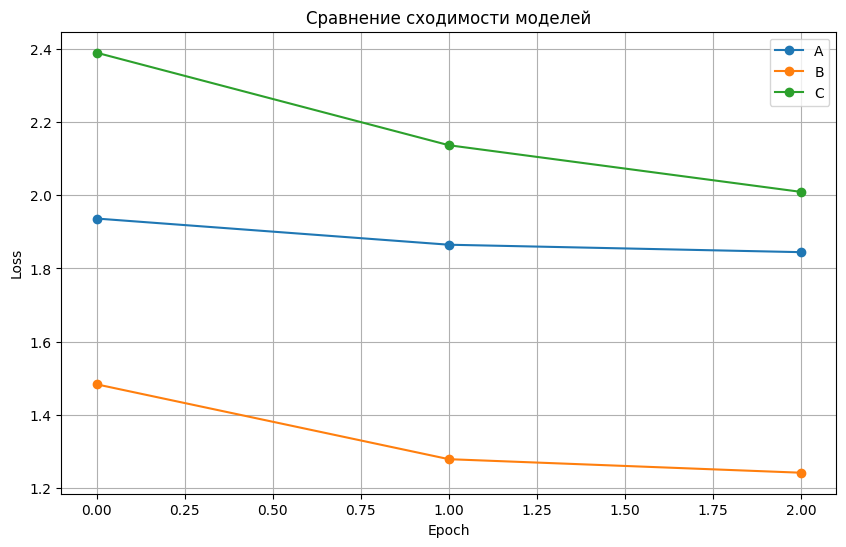


Время обучения
A: 265.46 сек.
B: 829.67 сек.
C: 2363.26 сек.

Сгенерированные тексты

A:
the company said this marker earl the reuter 3 ? fiviev ane york v...

B:
the company said the american said the soviet production over the ...

C:
the company said to it preention mers commuctrocation genation a s...


In [53]:
task = {
    "A": {"hidden_size": 64,  "num_layers": 1, "learning_rate": 0.01},
    "B": {"hidden_size": 256, "num_layers": 2, "learning_rate": 0.001},
    "C": {"hidden_size": 512, "num_layers": 3, "learning_rate": 0.008}
}

results = {}

for name, params in task.items():
    losses, time_taken, gen_text = train_t(**params, epochs=3)
    results[name] = {
        "losses": losses,
        "time": time_taken,
        "generated": gen_text
    }

plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(data["losses"], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Сравнение сходимости моделей")
plt.legend()
plt.grid(True)
plt.show()


print("\nВремя обучения")
for name, data in results.items():
    print(f"{name}: {data['time']:.2f} сек.")

print("\nСгенерированные тексты")
for name, data in results.items():
    print(f"\n{name}:\n{data['generated'][:300]}...")


### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?


Ответ: для синусоида не нужны словари или эмбеддинг, числа уже идут числами, не треубуется кодировния, стоит только добавить unsqueeze (для лстм-ки). В подготовке же текста важно привести все к одинаковой доступности, токенизация. Каждому уникальному символу - присвоить номер. Здесь же эмббединговый слой, а также наличие шума. Синусоида про математическую зависимость, текст про вероятности в структуре языка.


2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?


Ответ: работа с размерностями. Сначала я постоянно ловила ошибки типа "Expected hidden size n got n, пришлось поработать со структурой рекуррентных сетей.
По итогам рана можно сказать, что последняя моддель, модель C, оказалась значительно более ресурсоемкой, но менее эффективной. Что означает, что увеличение размера модели не всегда улучшает результат.